In [1]:
import os 
# Get the current working directory
current_dir = os.getcwd()
print("Current working directory:", current_dir)

import pandas as pd
import scanpy as sc
import anndata as ad
from tqdm import tqdm
import matplotlib.pyplot as plt # import matplotlib to visualize our qc metrics

# magic incantation to help matplotlib work with our jupyter notebook
%matplotlib inline 

Current working directory: /gpfs/commons/home/kisaev/Leaflet-analysis/tabula_sapien/exploratory


In [3]:
# muscle intron cluster with singletons
intron_clusters = "/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/Muscle_wsingleton_50_500000_2_1_0.005_single_cell.gz"
# read file
intron_clusts = pd.read_csv(intron_clusters, sep="}")
print(intron_clusts.head())

  chrom  chromStart  chromEnd           name  score strand  thickStart  \
0     1     2304585   2306019  JUNC000000010     27      +     2304530   
1     1    35188090  35189002  JUNC000000020     19      -    35188067   
2     1    35189087  35189185  JUNC000000030     15      -    35189001   
3     1    35189382  35190497  JUNC000000040      4      -    35189321   
4     1    44881739  44897354  JUNC000000060      2      -    44881668   

   thickEnd  itemRgb  blockCount  ... num_cells_wjunc  \
0   2306099  255,0,0           2  ...               1   
1  35189087  255,0,0           2  ...               1   
2  35189193  255,0,0           2  ...               1   
3  35190504  255,0,0           2  ...               1   
4  44897363  255,0,0           2  ...               1   

                                     cell_readcounts  block_add_start  \
0  TSP4_Muscle_rectusabdominus_SS2_B114997_B13404...               55   
1  TSP4_Muscle_rectusabdominus_SS2_B114997_B13404...              

In [17]:
# get unique dataframe of just Cluster, gene_id, junction_id and Count 
intron_clusts_unique = intron_clusts[["Cluster", "gene_id", "junction_id", "Count"]].drop_duplicates()
print(intron_clusts_unique.head())

   Cluster             gene_id          junction_id  Count
0     3232  ENSG00000157933.11    1_2304585_2306019      3
1     6600  ENSG00000116560.12  1_35188090_35189002      1
2     6601  ENSG00000116560.12  1_35189087_35189185      1
3     6602  ENSG00000116560.12  1_35189382_35190497      1
4     6071  ENSG00000070785.17  1_44881739_44897354      7


In [20]:
# how many clusters are singletons 
singletons = intron_clusts_unique[intron_clusts_unique["Count"] == 1]
print("Total number of singletons:", singletons.shape[0])

Total number of singletons: 151925


In [ ]:
intron_clusts_unique

In [21]:
# what is the total number of unique junctions 
print("Total number of unique junctions: ", intron_clusts_unique['junction_id'].nunique())
# what is the total number of intron_csluters (Cluster)
print("Total number of intron clusters: ", intron_clusts_unique['Cluster'].nunique())
# number of unique known genes captured 
print("Total number of unique known genes: ", intron_clusts_unique['gene_id'].nunique())

Total number of unique junctions:  239883
Total number of intron clusters:  116415
Total number of unique known genes:  21767


In [4]:
# Let's start with Lymph Node cells 
organ="Muscle"
input_files_folder="/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/"+organ+"/"
print(input_files_folder)

/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/Muscle/


In [5]:
print(input_files_folder)
# read each hdf file in folder and concatenate
files = os.listdir(input_files_folder)
df_list = []
for file in tqdm(files):
    print(file)
    if file.endswith(".h5"):
        path_with_quotes = input_files_folder + file
        fixed_path = path_with_quotes.replace("'", "")
        df = pd.read_hdf(fixed_path, 'df')
        df_list.append(df)
    else:
        pass
# concatenate all dataframes
summarized_data = pd.concat(df_list, ignore_index=True)

/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/Muscle/


  0%|          | 0/19 [00:00<?, ?it/s]

Muscle_mesenchymal stem cell.h5


  5%|▌         | 1/19 [00:07<02:10,  7.23s/it]

Muscle_macrophage.h5


...

 74%|███████▎  | 14/19 [00:17<00:05,  1.00s/it]

Muscle_mesothelial cell.h5
Muscle_cd4-positive, alpha-beta t cell.h5


 95%|█████████▍| 18/19 [00:18<00:00,  2.36it/s]

Muscle_smooth muscle cell.h5
Muscle_erythrocyte.h5
Muscle_mast cell.h5


100%|██████████| 19/19 [00:18<00:00,  1.03it/s]


In [6]:
summarized_data.head()

,cell_id,Cluster,Cluster_Counts,junction_id,gene_id,junc_count,cell_type,junc_ratio,cell_id_index,junction_id_index
0,B107909_A11_S239.homo.gencode.v30.ERCC.chrM,146,191,1_150156206_150156910,ENSG00000023902.14,71,mesenchymal stem cell,0.371728,308,60850
1,B107909_A11_S239.homo.gencode.v30.ERCC.chrM,146,191,1_150157015_150157384,ENSG00000023902.14,57,mesenchymal stem cell,0.298429,308,60852
2,B107909_A11_S239.homo.gencode.v30.ERCC.chrM,146,191,1_150157486_150158818,ENSG00000023902.14,63,mesenchymal stem cell,0.329843,308,60854
3,B107909_A11_S239.homo.gencode.v30.ERCC.chrM,476,28,1_42697262_42700780,ENSG00000065978.19,28,mesenchymal stem cell,1.000000,308,69568
4,B107909_A11_S239.homo.gencode.v30.ERCC.chrM,580,177,1_161674073_161677327,ENSG00000072694.22,177,mesenchymal stem cell,1.000000,308,63008


In [7]:
# [1]. How many cells are there in total for this organ?
print("Total number of cells in", organ, "is", len(summarized_data.cell_id.unique()))

Total number of cells in Muscle is 5004


In [8]:
# [2]. How many unique intron clusters are there in total for this organ? what about unique junctions ids? and unique genes?
print("Total number of unique intron clusters in", organ, "is", len(summarized_data.Cluster.unique()))
print("Total number of unique junctions in", organ, "is", len(summarized_data.junction_id.unique()))
print("Total number of unique genes in", organ, "is", len(summarized_data.gene_id.unique()))

Total number of unique intron clusters in Muscle is 28353
Total number of unique junctions in Muscle is 144382
Total number of unique genes in Muscle is 14159


In [9]:
# [3]. Plot distribution of number of junctions per cluster 
# First, let's get the number of unique junctions per cluster
unique_junctions_per_cluster = summarized_data.groupby('Cluster')['junction_id'].nunique().reset_index()
unique_junctions_per_cluster.columns = ['Cluster', 'unique_junctions']

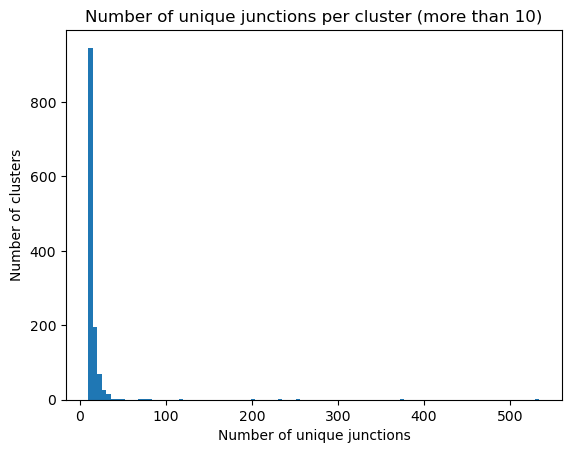

In [30]:
plt.hist(unique_junctions_per_cluster[unique_junctions_per_cluster["unique_junctions"]>=10].unique_junctions, bins=100)
# add plot
plt.title("Number of unique junctions per cluster (more than 10)")
plt.xlabel("Number of unique junctions")
plt.ylabel("Number of clusters")
plt.show()

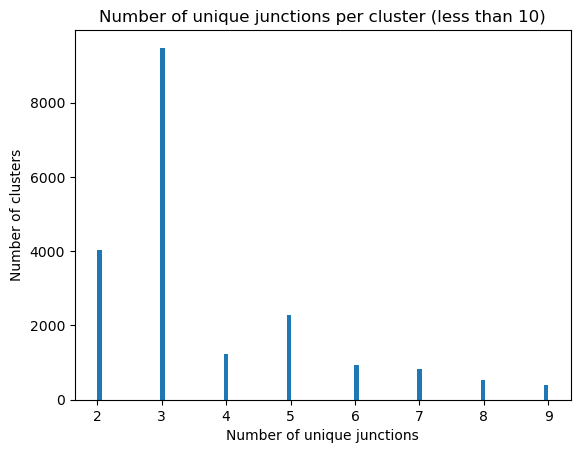

In [37]:
plt.hist(unique_junctions_per_cluster[unique_junctions_per_cluster["unique_junctions"]<10].unique_junctions, bins=100)
# add plot
plt.title("Number of unique junctions per cluster (less than 10)")
plt.xlabel("Number of unique junctions")
plt.ylabel("Number of clusters")
plt.show()

<Axes: >

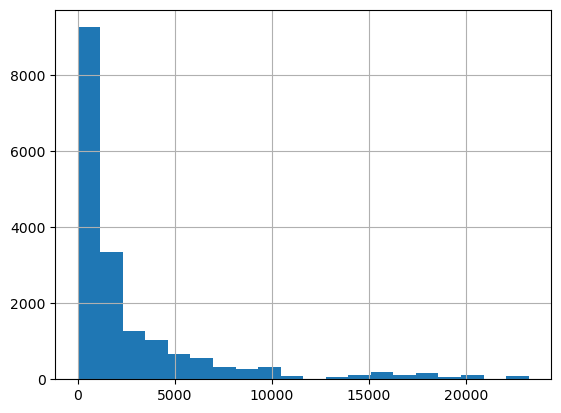

In [10]:
summarized_data[summarized_data["Cluster"] == 18240].Cluster_Counts.hist(bins=20)

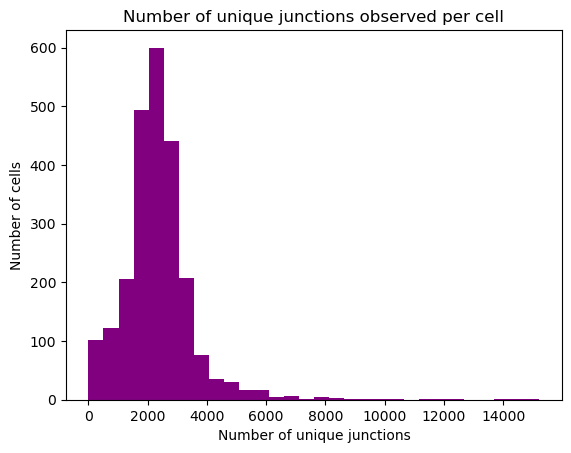

In [39]:
# Summarize how many unique junctions detected per unique cell 
unique_junctions_per_cell = summarized_data.groupby('cell_id')['junction_id'].nunique().reset_index()
unique_junctions_per_cell.columns = ['cell_id', 'unique_junctions']
# Make a histogram of the number of unique junctions per cell
plt.hist(unique_junctions_per_cell.unique_junctions, bins=30, color='purple')
# Add title 
plt.title("Number of unique junctions observed per cell")
# Add x axis label
plt.xlabel("Number of unique junctions")
# Add y axis label
plt.ylabel("Number of cells")
# Show plot
plt.show()

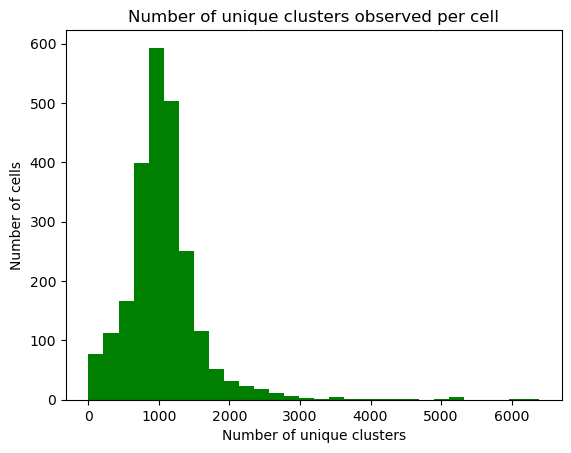

In [40]:
# Summarize how many unique clusters detected per unique cell 
unique_clusters_per_cell = summarized_data.groupby('cell_id')['Cluster'].nunique().reset_index()
unique_clusters_per_cell.columns = ['cell_id', 'unique_clusters']
# Make a histogram of the number of unique clusters per cell
plt.hist(unique_clusters_per_cell.unique_clusters, bins=30, color="green")
# add title
plt.title("Number of unique clusters observed per cell")
# add x axis label
plt.xlabel("Number of unique clusters")
# add y axis label
plt.ylabel("Number of cells")
# Show plot
plt.show()

<Axes: >

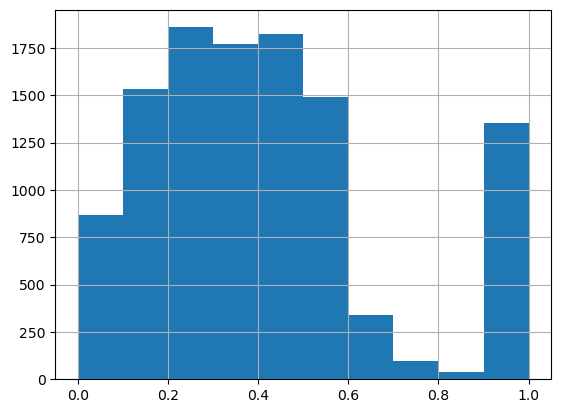

In [15]:
summarized_data[summarized_data["cell_id"] == "TSP2_LymphNode_supradiaphragmatic_SS2_B113242_B133056_ImmuneLinNeg_K9_S249"].junc_ratio.hist()

Text(0.5, 1.0, 'Total number of junction counts per cell')

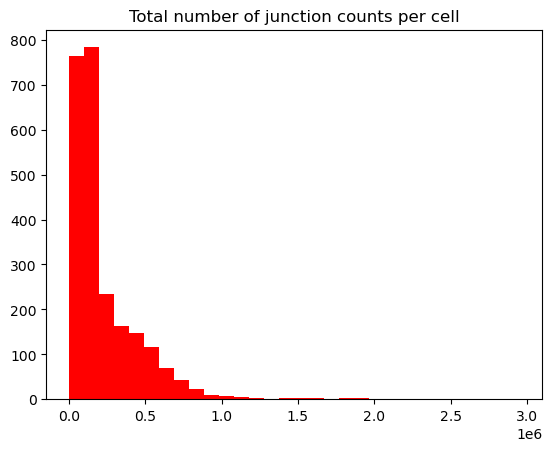

In [16]:
# summarize total number of junc_counts per unique cell 
total_junc_counts_per_cell = summarized_data.groupby('cell_id')['junc_count'].sum().reset_index()
total_junc_counts_per_cell.columns = ['cell_id', 'total_junc_counts']
# Make a histogram of the number of unique clusters per cell
plt.hist(total_junc_counts_per_cell.total_junc_counts, bins=30, color="red")
# add title 
plt.title("Total number of junction counts per cell")


In [41]:
# summarize number of junctions and clusters osberved per gene 
junctions_per_gene = summarized_data.groupby('gene_id')['junction_id'].nunique().reset_index()
junctions_per_gene.columns = ['gene_id', 'unique_junctions']
clusters_per_gene = summarized_data.groupby('gene_id')['Cluster'].nunique().reset_index()
clusters_per_gene.columns = ['gene_id', 'unique_clusters']

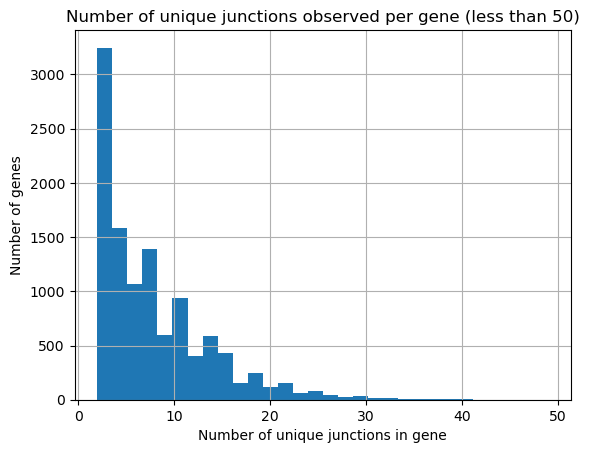

In [52]:
junctions_per_gene[junctions_per_gene["unique_junctions"]<50].unique_junctions.hist(bins=30)
# add title 
plt.title("Number of unique junctions observed per gene (less than 50)")
# add x axis label
plt.xlabel("Number of unique junctions in gene")
# add y axis label
plt.ylabel("Number of genes")
# Show plot
plt.show()

In [57]:
clusters_per_gene[clusters_per_gene["unique_clusters"] ==  12]

,gene_id,unique_clusters
70,ENSG00000005810.20,12


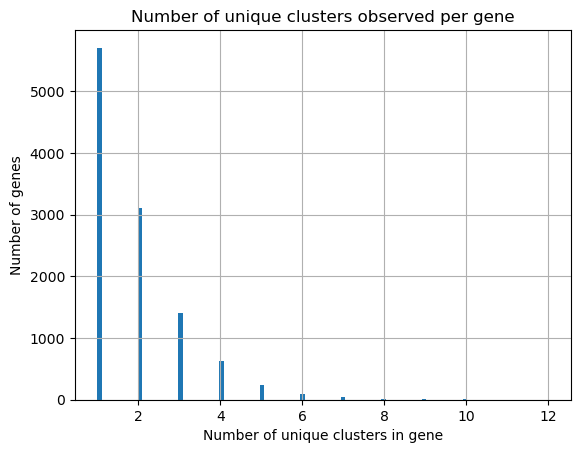

In [60]:
clusters_per_gene.unique_clusters.hist(bins=100)
# add title
plt.title("Number of unique clusters observed per gene")
# add x axis label
plt.xlabel("Number of unique clusters in gene")
# add y axis label
plt.ylabel("Number of genes")
# Show plot
plt.show()